# 🚛 Modelagem Preditiva com Cadeias de Markov
## Previsão de Eventos Críticos `Is_Dont_Go` em Caminhões de Mineração (Frota 793-D)

**Objetivo:** Construir um modelo baseado em Cadeias de Markov Absorventes para prever
a ocorrência do evento crítico `Is_Dont_Go` (parada não programada) em caminhões de mineração,
utilizando dados de telemetria e regras de alarmes.

**Metodologia:**
1. Janela deslizante de 4 horas (**lookback**) para capturar o histórico de alarmes por equipamento
2. Codificação de estados discretos (hashable) a partir do perfil de alarmes na janela
3. Construção da **Matriz de Transição de Probabilidades**
4. Cálculo de **probabilidade de absorção** (risco de falha) via Matriz Fundamental
5. Avaliação com divisão temporal e métricas de classificação

**Fundamentação Matemática:**

Seja $\mathbf{P}$ a matriz de transição da cadeia de Markov com um estado absorvente
$S_{\text{DG}}$ (Don't Go). Particionamos $\mathbf{P}$ em:

$$\mathbf{P} = \begin{pmatrix} \mathbf{Q} & \mathbf{R} \\ \mathbf{0} & \mathbf{I} \end{pmatrix}$$

onde $\mathbf{Q}$ é a submatriz de transição entre estados transientes e $\mathbf{R}$
contém as probabilidades de transição para o estado absorvente.

A **Matriz Fundamental** $\mathbf{N} = (\mathbf{I} - \mathbf{Q})^{-1}$ e as
**probabilidades de absorção** $\mathbf{B} = \mathbf{N} \cdot \mathbf{R}$ fornecem
a probabilidade de cada estado transiente atingir $S_{\text{DG}}$.

---
## Célula 1 — Importação de Bibliotecas

In [6]:
import pandas as pd
import numpy as np
from collections import defaultdict
from typing import Optional, Tuple, List, Dict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.dpi": 110,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "font.size": 11,
    }
)
sns.set_style("whitegrid")
sns.set_palette("viridis")

print("✅ Bibliotecas importadas com sucesso.")
print(f"   Pandas {pd.__version__} | NumPy {np.__version__}")

✅ Bibliotecas importadas com sucesso.
   Pandas 3.0.3 | NumPy 2.5.1


---
## Célula 2 — Criação do Mock DataFrame

Dados fictícios que simulam a telemetria de uma frota de caminhões 793-D.
Inclui padrões realistas de **escalonamento de alarmes** antes de eventos `Is_Dont_Go`,
para que a Cadeia de Markov consiga capturar sinais preditivos.

In [7]:
def create_mock_data(
    n_trucks: int = 5,
    n_days: int = 30,
    events_per_truck: int = 350,
    failures_range: Tuple[int, int] = (3, 6),
    seed: int = 42,
) -> pd.DataFrame:
    """
    Gera um DataFrame mock de telemetria de caminhões de mineração.

    Para cada caminhão, gera:
    - Eventos normais de rotina (alarmes de baixa/média criticidade)
    - Eventos de escalonamento pré-falha (alarmes crescentes nas 4h anteriores)
    - Eventos de falha Is_Dont_Go == 1

    Parameters
    ----------
    n_trucks : int
        Número de caminhões na frota.
    n_days : int
        Duração do período simulado em dias.
    events_per_truck : int
        Número médio de eventos normais por caminhão.
    failures_range : tuple
        Intervalo (min, max) de eventos Is_Dont_Go por caminhão.
    seed : int
        Semente para reprodutibilidade.

    Returns
    -------
    pd.DataFrame
        DataFrame com colunas: TAG, Data_Evento, Alarme, Criticidade, Valor, Classe, Is_Dont_Go
    """
    np.random.seed(seed)

    tags = [f"CAM793D-{str(i).zfill(3)}" for i in range(1, n_trucks + 1)]

    alarmes_normais = [
        "ALM_TEMP_MOTOR",
        "ALM_PRESS_OLEO",
        "ALM_VIBRACAO_CHASSI",
        "ALM_FREIO_DESGASTE",
        "ALM_TRANSMISSAO",
        "ALM_HIDRAULICO",
        "ALM_PNEU_PRESSAO",
        "ALM_ELETRICO_TENSAO",
    ]
    alarmes_pre_falha = [
        "ALM_TEMP_MOTOR",
        "ALM_PRESS_OLEO",
        "ALM_VIBRACAO_CHASSI",
        "ALM_SOBREAQUECIMENTO",
        "ALM_FALHA_FREIO",
    ]

    criticidades = ["BAIXA", "MEDIA", "ALTA", "CRITICA"]
    classes = ["MOTOR", "TRANSMISSAO", "FREIO", "ESTRUTURAL", "ELETRICA", "HIDRAULICA"]

    start_date = pd.Timestamp("2025-01-01")
    end_date = start_date + pd.Timedelta(days=n_days)

    records: List[dict] = []

    for tag in tags:
        # ── Eventos normais (operação de rotina) ──
        n_events = events_per_truck + np.random.randint(-50, 50)
        normal_timestamps = np.sort(
            np.random.uniform(start_date.value, end_date.value, size=n_events).astype(
                "int64"
            )
        )
        normal_times = pd.to_datetime(normal_timestamps)

        for t in normal_times:
            records.append(
                {
                    "TAG": tag,
                    "Data_Evento": t,
                    "Alarme": np.random.choice(alarmes_normais),
                    "Criticidade": np.random.choice(
                        criticidades, p=[0.45, 0.30, 0.18, 0.07]
                    ),
                    "Valor": round(np.random.uniform(10, 75), 1),
                    "Classe": np.random.choice(classes),
                    "Is_Dont_Go": 0,
                }
            )

        # ── Eventos de falha com escalonamento prévio ──
        n_failures = np.random.randint(*failures_range)
        candidate_times = pd.date_range(
            start_date + pd.Timedelta(days=3),
            end_date - pd.Timedelta(days=1),
            freq="8h",
        )
        failure_times = np.sort(
            np.random.choice(candidate_times, size=n_failures, replace=False)
        )

        for ft in failure_times:
            # Padrão de escalonamento: 6-9 alarmes crescentes nas 4h anteriores
            n_precursors = np.random.randint(6, 10)
            hours_before = np.sort(
                np.random.uniform(0.3, 3.8, size=n_precursors)
            )[::-1]

            for hb in hours_before:
                if hb > 2.5:
                    crit = np.random.choice(["MEDIA", "ALTA"], p=[0.6, 0.4])
                elif hb > 1.0:
                    crit = np.random.choice(["ALTA", "CRITICA"], p=[0.5, 0.5])
                else:
                    crit = "CRITICA"

                records.append(
                    {
                        "TAG": tag,
                        "Data_Evento": ft - pd.Timedelta(hours=hb),
                        "Alarme": np.random.choice(alarmes_pre_falha),
                        "Criticidade": crit,
                        "Valor": round(np.random.uniform(75, 100), 1),
                        "Classe": np.random.choice(classes),
                        "Is_Dont_Go": 0,
                    }
                )

            # O evento de falha em si
            records.append(
                {
                    "TAG": tag,
                    "Data_Evento": ft,
                    "Alarme": "ALM_PARADA_CRITICA",
                    "Criticidade": "CRITICA",
                    "Valor": 100.0,
                    "Classe": np.random.choice(classes),
                    "Is_Dont_Go": 1,
                }
            )

    df = pd.DataFrame(records)
    df["Data_Evento"] = pd.to_datetime(df["Data_Evento"])
    df = df.sort_values(["TAG", "Data_Evento"]).reset_index(drop=True)

    return df


# ── Criar e inspecionar os dados ──
df_raw = create_mock_data()

print(f"📊 Shape do DataFrame: {df_raw.shape}")
print(f"🚛 TAGs únicos: {df_raw['TAG'].nunique()}")
print(f"⚠️  Eventos Is_Dont_Go=1: {df_raw['Is_Dont_Go'].sum()}")
print(
    f"📅 Período: {df_raw['Data_Evento'].min().strftime('%Y-%m-%d %H:%M')} → "
    f"{df_raw['Data_Evento'].max().strftime('%Y-%m-%d %H:%M')}"
)
print(f"\n{'='*80}")
print("Amostra dos dados:")
print(f"{'='*80}")
display(df_raw.head(10)) if hasattr(__builtins__, "__IPYTHON__") else print(
    df_raw.head(10).to_string()
)

print(f"\n--- Distribuição de Criticidade ---")
print(df_raw["Criticidade"].value_counts().to_string())
print(f"\n--- Distribuição de Alarmes ---")
print(df_raw["Alarme"].value_counts().to_string())
print(f"\n--- Distribuição de Is_Dont_Go por TAG ---")
print(df_raw.groupby("TAG")["Is_Dont_Go"].sum().to_string())

📊 Shape do DataFrame: (1836, 7)
🚛 TAGs únicos: 5
⚠️  Eventos Is_Dont_Go=1: 17
📅 Período: 2025-01-01 00:14 → 2025-01-30 23:37

Amostra dos dados:


,TAG,Data_Evento,Alarme,Criticidade,Valor,Classe,Is_Dont_Go
0,CAM793D-001,2025-01-01 03:38:39.625329408,ALM_TRANSMISSAO,MEDIA,50.0,TRANSMISSAO,0
1,CAM793D-001,2025-01-01 03:58:33.327584256,ALM_TEMP_MOTOR,ALTA,51.4,ESTRUTURAL,0
2,CAM793D-001,2025-01-01 05:00:19.922336768,ALM_ELETRICO_TENSAO,MEDIA,47.3,MOTOR,0
3,CAM793D-001,2025-01-01 06:37:18.757790208,ALM_TEMP_MOTOR,ALTA,63.3,ESTRUTURAL,0
4,CAM793D-001,2025-01-01 10:21:47.922528256,ALM_VIBRACAO_CHASSI,ALTA,52.3,FREIO,0
5,CAM793D-001,2025-01-01 11:07:43.550042880,ALM_FREIO_DESGASTE,BAIXA,23.9,HIDRAULICA,0
6,CAM793D-001,2025-01-01 11:56:35.652581120,ALM_PRESS_OLEO,BAIXA,50.2,MOTOR,0
7,CAM793D-001,2025-01-01 14:49:15.009214720,ALM_PRESS_OLEO,BAIXA,64.9,TRANSMISSAO,0
8,CAM793D-001,2025-01-01 17:30:26.984990208,ALM_HIDRAULICO,ALTA,28.3,ESTRUTURAL,0
9,CAM793D-001,2025-01-01 18:15:09.126932992,ALM_PRESS_OLEO,MEDIA,50.9,ELETRICA,0



--- Distribuição de Criticidade ---
Criticidade
BAIXA      750
MEDIA      545
ALTA       359
CRITICA    182

--- Distribuição de Alarmes ---
Alarme
ALM_VIBRACAO_CHASSI     245
ALM_TEMP_MOTOR          244
ALM_PRESS_OLEO          233
ALM_HIDRAULICO          226
ALM_PNEU_PRESSAO        224
ALM_TRANSMISSAO         207
ALM_FREIO_DESGASTE      203
ALM_ELETRICO_TENSAO     192
ALM_FALHA_FREIO          30
ALM_PARADA_CRITICA       17
ALM_SOBREAQUECIMENTO     15

--- Distribuição de Is_Dont_Go por TAG ---
TAG
CAM793D-001    3
CAM793D-002    3
CAM793D-003    5
CAM793D-004    3
CAM793D-005    3


---
## Célula 3 — Engenharia de Features

### Regras implementadas:
1. **Isolamento por TAG**: Todo processamento de janelas é isolado por equipamento
2. **Lookback (4h para trás)**: Para cada evento em $t$, captura eventos em $[t - 4h, t]$
3. **Codificação de Estado**: Transforma o perfil da janela em uma string hashable
   com binning para controlar explosão de estados
4. **Target (4h para frente)**: Verifica se há `Is_Dont_Go == 1` em $(t, t + 4h]$

### Otimizações:
- `pd.merge_asof` para cálculo do target (O(n log n))
- Self-merge + `pivot_table` para features de lookback (vetorizado)
- Codificação de estados via operações vetorizadas de string do Pandas

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                         CONSTANTES GLOBAIS                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝

LOOKBACK_HOURS = 4
LOOKAHEAD_HOURS = 4
ABSORBING_STATE = "__DONT_GO__"

# Limites de binning para evitar explosão combinatória de estados.
# Cada feature é "clippada" a estes valores máximos antes da codificação.
BIN_LIMITS = {
    "n_events": 10,  # máx 11 valores (0..10)
    "n_unique": 6,  # máx 7 valores (0..6)
    "crit_baixa": 4,  # máx 5 valores (0..4)
    "crit_media": 4,  # máx 5 valores (0..4)
    "crit_alta": 3,  # máx 4 valores (0..3)
    "crit_critica": 2,  # máx 3 valores (0..2)
}
# Espaço teórico máximo: 11 × 7 × 5 × 5 × 4 × 3 = 23.100 estados
# Na prática, apenas uma fração desses estados será observada.


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                     CÁLCULO DO TARGET (LOOKAHEAD)                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝


def compute_target_lookahead(df: pd.DataFrame) -> pd.Series:
    """
    Para cada linha no instante t, verifica se existe algum evento
    Is_Dont_Go == 1 para o mesmo TAG no intervalo futuro (t, t + 4h].

    Utiliza pd.merge_asof com direction='forward' para encontrar o próximo
    evento de falha de forma eficiente — O(n log n).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com colunas ['row_id', 'TAG', 'Data_Evento', 'Is_Dont_Go'],
        já ordenado por ['TAG', 'Data_Evento'].

    Returns
    -------
    pd.Series
        Série binária (0/1) indexada por row_id.
    """
    # Isolar eventos de falha
    dg = df.loc[df["Is_Dont_Go"] == 1, ["TAG", "Data_Evento"]].copy()
    dg = dg.rename(columns={"Data_Evento": "Next_DG_Time"})
    dg = dg.sort_values("Next_DG_Time").reset_index(drop=True)

    if dg.empty:
        return pd.Series(0, index=df["row_id"], name="Target_4h")

    # Ordenar por tempo para o merge_asof
    df_sorted = df[["row_id", "TAG", "Data_Evento"]].sort_values("Data_Evento")

    # merge_asof: encontra o próximo evento DG futuro para o mesmo TAG
    merged = pd.merge_asof(
        df_sorted,
        dg,
        left_on="Data_Evento",
        right_on="Next_DG_Time",
        by="TAG",
        direction="forward",
        allow_exact_matches=False,  # Intervalo aberto em t: (t, t+4h]
    )

    # Target = 1 se o próximo DG está dentro de 4h
    merged["Target_4h"] = (
        (merged["Next_DG_Time"] - merged["Data_Evento"])
        <= pd.Timedelta(hours=LOOKAHEAD_HOURS)
    ).fillna(False).astype(int)

    return merged.set_index("row_id")["Target_4h"]


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                   FEATURES DA JANELA DE LOOKBACK                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝


def compute_lookback_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Para cada linha no instante t, captura todos os eventos do mesmo TAG
    no intervalo [t - 4h, t] e agrega features numéricas.

    Estratégia vetorizada:
    1. Self-merge no TAG para gerar todos os pares possíveis dentro do grupo
    2. Filtro temporal vetorizado na janela [t - 4h, t]
    3. Agregação via pivot_table (criticidade) e groupby (contagens)

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com colunas ['row_id', 'TAG', 'Data_Evento', 'Alarme', 'Criticidade'].

    Returns
    -------
    pd.DataFrame
        Features agregadas indexadas por row_id:
        - n_events: total de eventos na janela
        - n_unique_alarms: alarmes distintos na janela
        - crit_baixa, crit_media, crit_alta, crit_critica: contagens por criticidade
    """
    # ── Self-merge no TAG ──
    left = df[["row_id", "TAG", "Data_Evento"]].copy()
    right = df[["TAG", "Data_Evento", "Alarme", "Criticidade"]].copy()
    right.columns = ["TAG", "dt_w", "alarme_w", "crit_w"]

    merged = left.merge(right, on="TAG")

    # ── Filtro temporal da janela [t - 4h, t] ──
    t_min = merged["Data_Evento"] - pd.Timedelta(hours=LOOKBACK_HOURS)
    mask = (merged["dt_w"] >= t_min) & (merged["dt_w"] <= merged["Data_Evento"])
    window = merged.loc[mask].copy()

    del merged  # Liberar memória

    # ── Contagens básicas ──
    basic_agg = window.groupby("row_id").agg(
        n_events=("alarme_w", "size"),
        n_unique_alarms=("alarme_w", "nunique"),
    )

    # ── Contagens de criticidade via pivot_table (mais eficiente que lambdas) ──
    window["_one"] = 1
    crit_pivot = window.pivot_table(
        index="row_id",
        columns="crit_w",
        values="_one",
        aggfunc="sum",
        fill_value=0,
    )
    # Padronizar nomes das colunas
    rename_map = {
        "BAIXA": "crit_baixa",
        "MEDIA": "crit_media",
        "ALTA": "crit_alta",
        "CRITICA": "crit_critica",
    }
    crit_pivot = crit_pivot.rename(columns=rename_map)

    # Garantir que todas as colunas de criticidade existam
    for col_name in rename_map.values():
        if col_name not in crit_pivot.columns:
            crit_pivot[col_name] = 0

    # ── Juntar tudo ──
    features = basic_agg.join(crit_pivot[list(rename_map.values())])

    return features


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                     CODIFICAÇÃO DE ESTADOS                             ║
# ╚══════════════════════════════════════════════════════════════════════════╝


def encode_states_vectorized(df: pd.DataFrame) -> pd.Series:
    """
    Codifica as features da janela de lookback em estados discretos (hashable).

    Aplica binning (clipping) em cada feature para controlar a explosão
    combinatória do espaço de estados. O estado resultante é uma string:

        "E{n_events}|U{n_unique}|B{baixa}|M{media}|A{alta}|C{critica}"

    Exemplo: "E5|U3|B2|M1|A2|C1" — 5 eventos, 3 alarmes únicos,
    2 baixa, 1 média, 2 alta, 1 crítica na janela de 4h.

    Operação 100% vetorizada via operações de string do Pandas.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com as features de lookback.

    Returns
    -------
    pd.Series
        Estados codificados como strings.
    """
    e = df["n_events"].clip(upper=BIN_LIMITS["n_events"]).astype(int).astype(str)
    u = (
        df["n_unique_alarms"]
        .clip(upper=BIN_LIMITS["n_unique"])
        .astype(int)
        .astype(str)
    )
    b = df["crit_baixa"].clip(upper=BIN_LIMITS["crit_baixa"]).astype(int).astype(str)
    m = df["crit_media"].clip(upper=BIN_LIMITS["crit_media"]).astype(int).astype(str)
    a = df["crit_alta"].clip(upper=BIN_LIMITS["crit_alta"]).astype(int).astype(str)
    c = (
        df["crit_critica"]
        .clip(upper=BIN_LIMITS["crit_critica"])
        .astype(int)
        .astype(str)
    )

    return "E" + e + "|U" + u + "|B" + b + "|M" + m + "|A" + a + "|C" + c


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                 CONSTRUÇÃO DE PARES DE TRANSIÇÃO                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝


def build_transitions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Constrói os pares de transição (from_state → to_state) para a Cadeia de Markov.

    Regras:
    - Transições ocorrem entre eventos *consecutivos* do mesmo TAG (ordem temporal).
    - Se o próximo evento tem Is_Dont_Go == 1, a transição destino é o estado absorvente.
    - Transições originadas de eventos Is_Dont_Go == 1 são **excluídas**
      (o estado absorvente não possui transições de saída durante o treinamento).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com colunas ['TAG', 'Data_Evento', 'state', 'Is_Dont_Go'].

    Returns
    -------
    pd.DataFrame
        DataFrame com colunas ['from_state', 'to_state'].
    """
    df_t = df[["TAG", "Data_Evento", "state", "Is_Dont_Go"]].copy()
    df_t = df_t.sort_values(["TAG", "Data_Evento"]).reset_index(drop=True)

    # Propriedades do próximo evento no mesmo TAG
    df_t["next_state"] = df_t.groupby("TAG")["state"].shift(-1)
    df_t["next_is_dg"] = df_t.groupby("TAG")["Is_Dont_Go"].shift(-1)

    # Se o próximo evento é DG → transição para estado absorvente
    df_t["to_state"] = np.where(
        df_t["next_is_dg"] == 1, ABSORBING_STATE, df_t["next_state"]
    )

    # Filtrar: apenas de estados transientes e com próximo evento existente
    valid_mask = (df_t["Is_Dont_Go"] == 0) & df_t["to_state"].notna()
    transitions = df_t.loc[valid_mask, ["state", "to_state"]].rename(
        columns={"state": "from_state"}
    )

    return transitions.reset_index(drop=True)


# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                     PIPELINE DE FEATURE ENGINEERING                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline completo de engenharia de features.

    Etapas:
    1. Cálculo do target binário (lookahead 4h) via merge_asof
    2. Cálculo das features da janela de lookback (4h) via self-merge
    3. Codificação vetorizada de estados discretos

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame bruto com colunas: TAG, Data_Evento, Alarme, Criticidade,
        Valor, Classe, Is_Dont_Go.

    Returns
    -------
    pd.DataFrame
        DataFrame enriquecido com features, estados e target.
    """
    df = df.sort_values(["TAG", "Data_Evento"]).reset_index(drop=True)
    df["row_id"] = df.index

    # ── Etapa 1: Target ──
    print("⏳ [1/3] Calculando Target_4h (lookahead)...")
    df["Target_4h"] = compute_target_lookahead(df).reindex(df["row_id"]).values

    # ── Etapa 2: Features de Lookback ──
    print("⏳ [2/3] Calculando features da janela de lookback (4h)...")
    lookback_feats = compute_lookback_features(df)
    df = df.join(lookback_feats, on="row_id")

    # Preencher NaNs (linhas sem eventos na janela — raro)
    feature_cols = [
        "n_events",
        "n_unique_alarms",
        "crit_baixa",
        "crit_media",
        "crit_alta",
        "crit_critica",
    ]
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0
    df[feature_cols] = df[feature_cols].fillna(0)

    # ── Etapa 3: Codificação de Estados ──
    print("⏳ [3/3] Codificando estados discretos...")
    df["state"] = encode_states_vectorized(df)

    # ── Resumo ──
    n_states = df["state"].nunique()
    n_target = df["Target_4h"].sum()
    pct_target = 100 * df["Target_4h"].mean()

    print(f"\n✅ Feature engineering concluída!")
    print(f"   • Linhas processadas: {len(df):,}")
    print(f"   • Estados únicos:     {n_states}")
    print(f"   • Target_4h = 1:      {n_target} ({pct_target:.1f}%)")
    print(f"   • Target_4h = 0:      {len(df) - n_target} ({100 - pct_target:.1f}%)")

    return df


# ═══════════════════════════════════════════════════════════════════════════
# EXECUTAR O PIPELINE
# ═══════════════════════════════════════════════════════════════════════════

df = engineer_features(df_raw.copy())

print(f"\n{'='*80}")
print("Amostra com features e estados:")
print(f"{'='*80}")
cols_show = [
    "TAG",
    "Data_Evento",
    "Alarme",
    "Criticidade",
    "Is_Dont_Go",
    "n_events",
    "crit_alta",
    "crit_critica",
    "state",
    "Target_4h",
]
print(df[cols_show].head(15).to_string())

print(f"\n--- Top 15 Estados mais frequentes ---")
print(df["state"].value_counts().head(15).to_string())

⏳ [1/3] Calculando Target_4h (lookahead)...
⏳ [2/3] Calculando features da janela de lookback (4h)...
⏳ [3/3] Codificando estados discretos...

✅ Feature engineering concluída!
   • Linhas processadas: 1,836
   • Estados únicos:     362
   • Target_4h = 1:      148 (8.1%)
   • Target_4h = 0:      1688 (91.9%)

Amostra com features e estados:
            TAG                   Data_Evento               Alarme Criticidade  Is_Dont_Go  n_events  crit_alta  crit_critica              state  Target_4h
0   CAM793D-001 2025-01-01 03:38:39.625329408      ALM_TRANSMISSAO       MEDIA           0         1          0             0  E1|U1|B0|M1|A0|C0          0
1   CAM793D-001 2025-01-01 03:58:33.327584256       ALM_TEMP_MOTOR        ALTA           0         2          1             0  E2|U2|B0|M1|A1|C0          0
2   CAM793D-001 2025-01-01 05:00:19.922336768  ALM_ELETRICO_TENSAO       MEDIA           0         3          1             0  E3|U3|B0|M2|A1|C0          0
3   CAM793D-001 2025-01-01 06:37

---
## Célula 4 — Implementação da Cadeia de Markov

### Classe `MarkovChainPredictor`

Implementa uma **Cadeia de Markov Absorvente** com:

- **`fit()`**: Constrói a Matriz de Transição a partir dos pares observados.
  Utiliza `np.add.at` para construção vetorizada da matriz de contagem.

- **Matriz Fundamental**: $\mathbf{N} = (\mathbf{I} - \mathbf{Q})^{-1}$

- **Probabilidades de Absorção**: $\mathbf{B} = \mathbf{N} \cdot \mathbf{R}$

- **N-Step Risk**: $P^n[S_i, S_{\text{DG}}]$ — probabilidade de atingir
  o estado absorvente em exatamente $n$ passos.

- **`predict_proba()`**: Mapeia cada estado para uma pontuação de risco contínua $[0, 1]$.

In [9]:
class MarkovChainPredictor:
    """
    Preditor de falhas baseado em Cadeia de Markov Absorvente.

    Modela as transições entre estados de alarme de equipamentos
    e calcula a probabilidade de atingir o estado absorvente
    (Is_Dont_Go == 1).

    Parameters
    ----------
    n_steps : int, default=5
        Número de passos para cálculo da probabilidade n-step.
        Representa o horizonte de transições futuras considerado.
    smoothing : float, default=1e-6
        Suavização de Laplace adicionada à matriz de contagem para
        evitar probabilidades exatamente zero.

    Attributes
    ----------
    P_ : np.ndarray
        Matriz de Transição de Probabilidades (n_states × n_states).
    states_ : list[str]
        Lista ordenada de todos os estados.
    risk_scores_ : dict[str, float]
        Score de risco (n-step) para cada estado.
    absorption_probs_ : dict[str, float]
        Probabilidade de absorção (horizonte infinito) para cada estado.

    Examples
    --------
    >>> mc = MarkovChainPredictor(n_steps=5)
    >>> mc.fit(transitions_df)
    >>> risk = mc.predict_proba(df_test['state'])
    """

    ABSORBING_STATE = "__DONT_GO__"

    def __init__(self, n_steps: int = 5, smoothing: float = 1e-6):
        self.n_steps = n_steps
        self.smoothing = smoothing
        # Atributos preenchidos no fit()
        self.states_: List[str] = []
        self.state_to_idx_: Dict[str, int] = {}
        self.P_: Optional[np.ndarray] = None
        self.count_matrix_: Optional[np.ndarray] = None
        self.n_states_: int = 0
        self.risk_scores_: Dict[str, float] = {}
        self.absorption_probs_: Dict[str, float] = {}

    def fit(self, transitions: pd.DataFrame) -> "MarkovChainPredictor":
        """
        Constrói a Matriz de Transição a partir dos pares de transição observados.

        Parameters
        ----------
        transitions : pd.DataFrame
            DataFrame com colunas ['from_state', 'to_state'].

        Returns
        -------
        self
            Instância fitted.
        """
        # ── Coletar todos os estados ──
        all_states = set(transitions["from_state"].unique()) | set(
            transitions["to_state"].unique()
        )
        if self.ABSORBING_STATE not in all_states:
            all_states.add(self.ABSORBING_STATE)

        self.states_ = sorted(all_states)
        self.state_to_idx_ = {s: i for i, s in enumerate(self.states_)}
        self.n_states_ = len(self.states_)

        # ── Construir Matriz de Contagem (vetorizado) ──
        count_matrix = np.zeros((self.n_states_, self.n_states_))

        from_idx = transitions["from_state"].map(self.state_to_idx_).values
        to_idx = transitions["to_state"].map(self.state_to_idx_).values

        # np.add.at para contagem vetorizada sem race conditions
        np.add.at(count_matrix, (from_idx, to_idx), 1)
        self.count_matrix_ = count_matrix.copy()

        # ── Normalizar → Probabilidades (com suavização de Laplace) ──
        count_matrix += self.smoothing
        row_sums = count_matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # Proteção contra divisão por zero
        self.P_ = count_matrix / row_sums

        # ── Forçar estado absorvente ──
        dg_idx = self.state_to_idx_[self.ABSORBING_STATE]
        self.P_[dg_idx, :] = 0.0
        self.P_[dg_idx, dg_idx] = 1.0

        # ── Calcular scores de risco ──
        print(f"   📐 Calculando risco n-step (n={self.n_steps})...")
        self._compute_nstep_risk()

        print(f"   📐 Calculando probabilidades de absorção (Matriz Fundamental)...")
        self._compute_absorption_probabilities()

        # ── Resumo ──
        print(f"\n✅ Cadeia de Markov treinada!")
        print(f"   • Estados:         {self.n_states_}")
        print(
            f"   • Transições:      {int(self.count_matrix_.sum()):,}"
        )
        print(
            f"   • Risco médio (n-step):     {np.mean(list(self.risk_scores_.values())):.4f}"
        )
        if self.absorption_probs_:
            print(
                f"   • Risco médio (absorção):   {np.mean(list(self.absorption_probs_.values())):.4f}"
            )

        return self

    def _compute_nstep_risk(self):
        """
        Calcula P(atingir DONT_GO em até n_steps passos) para cada estado.

        Utiliza potência de matrizes: P^n[i, j_DG].
        Como DONT_GO é absorvente, P^n[i, DG] = P(absorção em ≤ n passos | S_i).
        """
        dg_idx = self.state_to_idx_[self.ABSORBING_STATE]
        P_n = np.linalg.matrix_power(self.P_, self.n_steps)

        for state, idx in self.state_to_idx_.items():
            self.risk_scores_[state] = float(np.clip(P_n[idx, dg_idx], 0, 1))

    def _compute_absorption_probabilities(self):
        """
        Calcula as probabilidades de absorção de horizonte infinito
        usando a Matriz Fundamental da Cadeia Absorvente.

        Teoria:
        - Q = submatriz de transição entre estados transientes
        - R = submatriz de transição de transientes → absorventes
        - N = (I - Q)^{-1}  (Matriz Fundamental)
        - B = N · R          (Probabilidades de Absorção)

        B[i, 0] = P(estado transiente i ser eventualmente absorvido)
        """
        dg_idx = self.state_to_idx_[self.ABSORBING_STATE]

        absorbing = {dg_idx}
        transient = [i for i in range(self.n_states_) if i not in absorbing]

        if not transient:
            return

        # Submatrizes Q e R
        Q = self.P_[np.ix_(transient, transient)]
        R = self.P_[np.ix_(transient, [dg_idx])]

        try:
            I = np.eye(len(transient))
            N = np.linalg.inv(I - Q)  # Matriz Fundamental
            B = N @ R  # Probabilidades de absorção

            for i, tidx in enumerate(transient):
                state = self.states_[tidx]
                self.absorption_probs_[state] = float(np.clip(B[i, 0], 0, 1))

            # Estado absorvente tem probabilidade 1
            self.absorption_probs_[self.ABSORBING_STATE] = 1.0

        except np.linalg.LinAlgError:
            print("   ⚠️  Matriz (I - Q) singular. Usando n-step como fallback.")
            self.absorption_probs_ = dict(self.risk_scores_)

    def predict_proba(
        self, states: pd.Series, method: str = "nstep"
    ) -> np.ndarray:
        """
        Mapeia uma série de estados codificados para scores de risco contínuos [0, 1].

        Parameters
        ----------
        states : pd.Series
            Série com os estados codificados (strings).
        method : str, default='nstep'
            Método de cálculo do risco:
            - 'nstep': P(atingir DG em n passos) — horizonte finito
            - 'absorption': P(eventualmente atingir DG) — horizonte infinito

        Returns
        -------
        np.ndarray
            Array de scores de risco entre 0 e 1.
        """
        scores = (
            self.risk_scores_ if method == "nstep" else self.absorption_probs_
        )

        # Estados desconhecidos → mediana dos scores conhecidos (robusto a outliers)
        known_values = list(scores.values())
        default = float(np.median(known_values)) if known_values else 0.0

        return np.array([scores.get(s, default) for s in states])

    def predict(
        self,
        states: pd.Series,
        threshold: float = 0.5,
        method: str = "nstep",
    ) -> np.ndarray:
        """
        Predição binária baseada em threshold.

        Parameters
        ----------
        states : pd.Series
            Estados codificados.
        threshold : float, default=0.5
            Limiar de decisão.
        method : str, default='nstep'
            Método de scoring ('nstep' ou 'absorption').

        Returns
        -------
        np.ndarray
            Array binário (0/1).
        """
        probas = self.predict_proba(states, method=method)
        return (probas >= threshold).astype(int)

    def get_transition_matrix_df(self) -> pd.DataFrame:
        """Retorna a Matriz de Transição como DataFrame para inspeção."""
        return pd.DataFrame(
            self.P_, index=self.states_, columns=self.states_
        )

    def get_top_risk_states(self, n: int = 20, method: str = "nstep") -> pd.DataFrame:
        """Retorna os N estados com maior score de risco."""
        scores = (
            self.risk_scores_ if method == "nstep" else self.absorption_probs_
        )
        df_risk = pd.DataFrame(
            [
                {"state": k, "risk_score": v}
                for k, v in sorted(
                    scores.items(), key=lambda x: x[1], reverse=True
                )
            ]
        )
        return df_risk.head(n)


# ═══════════════════════════════════════════════════════════════════════════
# TREINAMENTO DO MODELO
# ═══════════════════════════════════════════════════════════════════════════

# ── Divisão Temporal: treino no passado, teste no futuro ──
split_date = df["Data_Evento"].quantile(0.70)
df_train = df[df["Data_Evento"] <= split_date].copy()
df_test = df[df["Data_Evento"] > split_date].copy()

print(f"📅 Data de corte: {split_date.strftime('%Y-%m-%d %H:%M')}")
print(f"   Treino: {len(df_train):,} linhas | Target=1: {df_train['Target_4h'].sum()}")
print(f"   Teste:  {len(df_test):,} linhas  | Target=1: {df_test['Target_4h'].sum()}")

# ── Construir transições do treino ──
print(f"\n⏳ Construindo pares de transição (treino)...")
train_transitions = build_transitions(df_train)
print(f"   Transições extraídas: {len(train_transitions):,}")

# ── Treinar a Cadeia de Markov ──
print(f"\n⏳ Treinando Cadeia de Markov...\n")
mc_model = MarkovChainPredictor(n_steps=5, smoothing=1e-6)
mc_model.fit(train_transitions)

# ── Predições ──
df_test["risk_nstep"] = mc_model.predict_proba(df_test["state"], method="nstep")
df_test["risk_absorption"] = mc_model.predict_proba(
    df_test["state"], method="absorption"
)

# ── Top estados de risco ──
print(f"\n{'='*60}")
print("🔴 Top 15 Estados com Maior Risco (N-Step)")
print(f"{'='*60}")
print(mc_model.get_top_risk_states(15, method="nstep").to_string(index=False))

📅 Data de corte: 2025-01-22 02:40
   Treino: 1,285 linhas | Target=1: 85
   Teste:  551 linhas  | Target=1: 63

⏳ Construindo pares de transição (treino)...
   Transições extraídas: 1,270

⏳ Treinando Cadeia de Markov...

   📐 Calculando risco n-step (n=5)...
   📐 Calculando probabilidades de absorção (Matriz Fundamental)...

✅ Cadeia de Markov treinada!
   • Estados:         275
   • Transições:      1,270
   • Risco médio (n-step):     0.1637
   • Risco médio (absorção):   1.0000

🔴 Top 15 Estados com Maior Risco (N-Step)
             state  risk_score
       __DONT_GO__    1.000000
E10|U4|B1|M1|A3|C1    0.999762
E10|U6|B1|M2|A2|C2    0.999762
 E7|U4|B0|M1|A3|C2    0.999762
 E8|U4|B1|M1|A3|C2    0.999762
 E8|U5|B0|M3|A3|C1    0.999762
 E8|U5|B1|M2|A2|C2    0.999762
 E9|U6|B0|M2|A3|C2    0.999762
 E9|U6|B2|M3|A2|C2    0.999762
 E9|U4|B1|M1|A3|C0    0.999514
 E7|U5|B1|M2|A2|C2    0.999514
 E7|U5|B0|M3|A3|C1    0.999514
 E6|U3|B0|M1|A3|C2    0.999514
 E7|U4|B1|M1|A2|C2    0.999514
 E8|U

---
## Célula 5 — Avaliação do Modelo

### Métricas e Visualizações:
1. **ROC-AUC** e Curva ROC
2. **Precision-Recall** e Average Precision
3. **Matriz de Confusão** com threshold ótimo (Youden's J)
4. **Distribuição de Risk Scores** por classe
5. **Evolução temporal** do risco para um caminhão específico


📊 AVALIAÇÃO — Método: N-Step (n=5)

   ROC-AUC:                0.8060
   Average Precision (AP): 0.3420
   Threshold ótimo (J):    0.0000
   Precision:              0.3588
   Recall:                 0.7460
   F1-Score:               0.4845

--- Classification Report ---
              precision    recall  f1-score   support

  Normal (0)       0.96      0.83      0.89       488
 Dont_Go (1)       0.36      0.75      0.48        63

    accuracy                           0.82       551
   macro avg       0.66      0.79      0.69       551
weighted avg       0.89      0.82      0.84       551



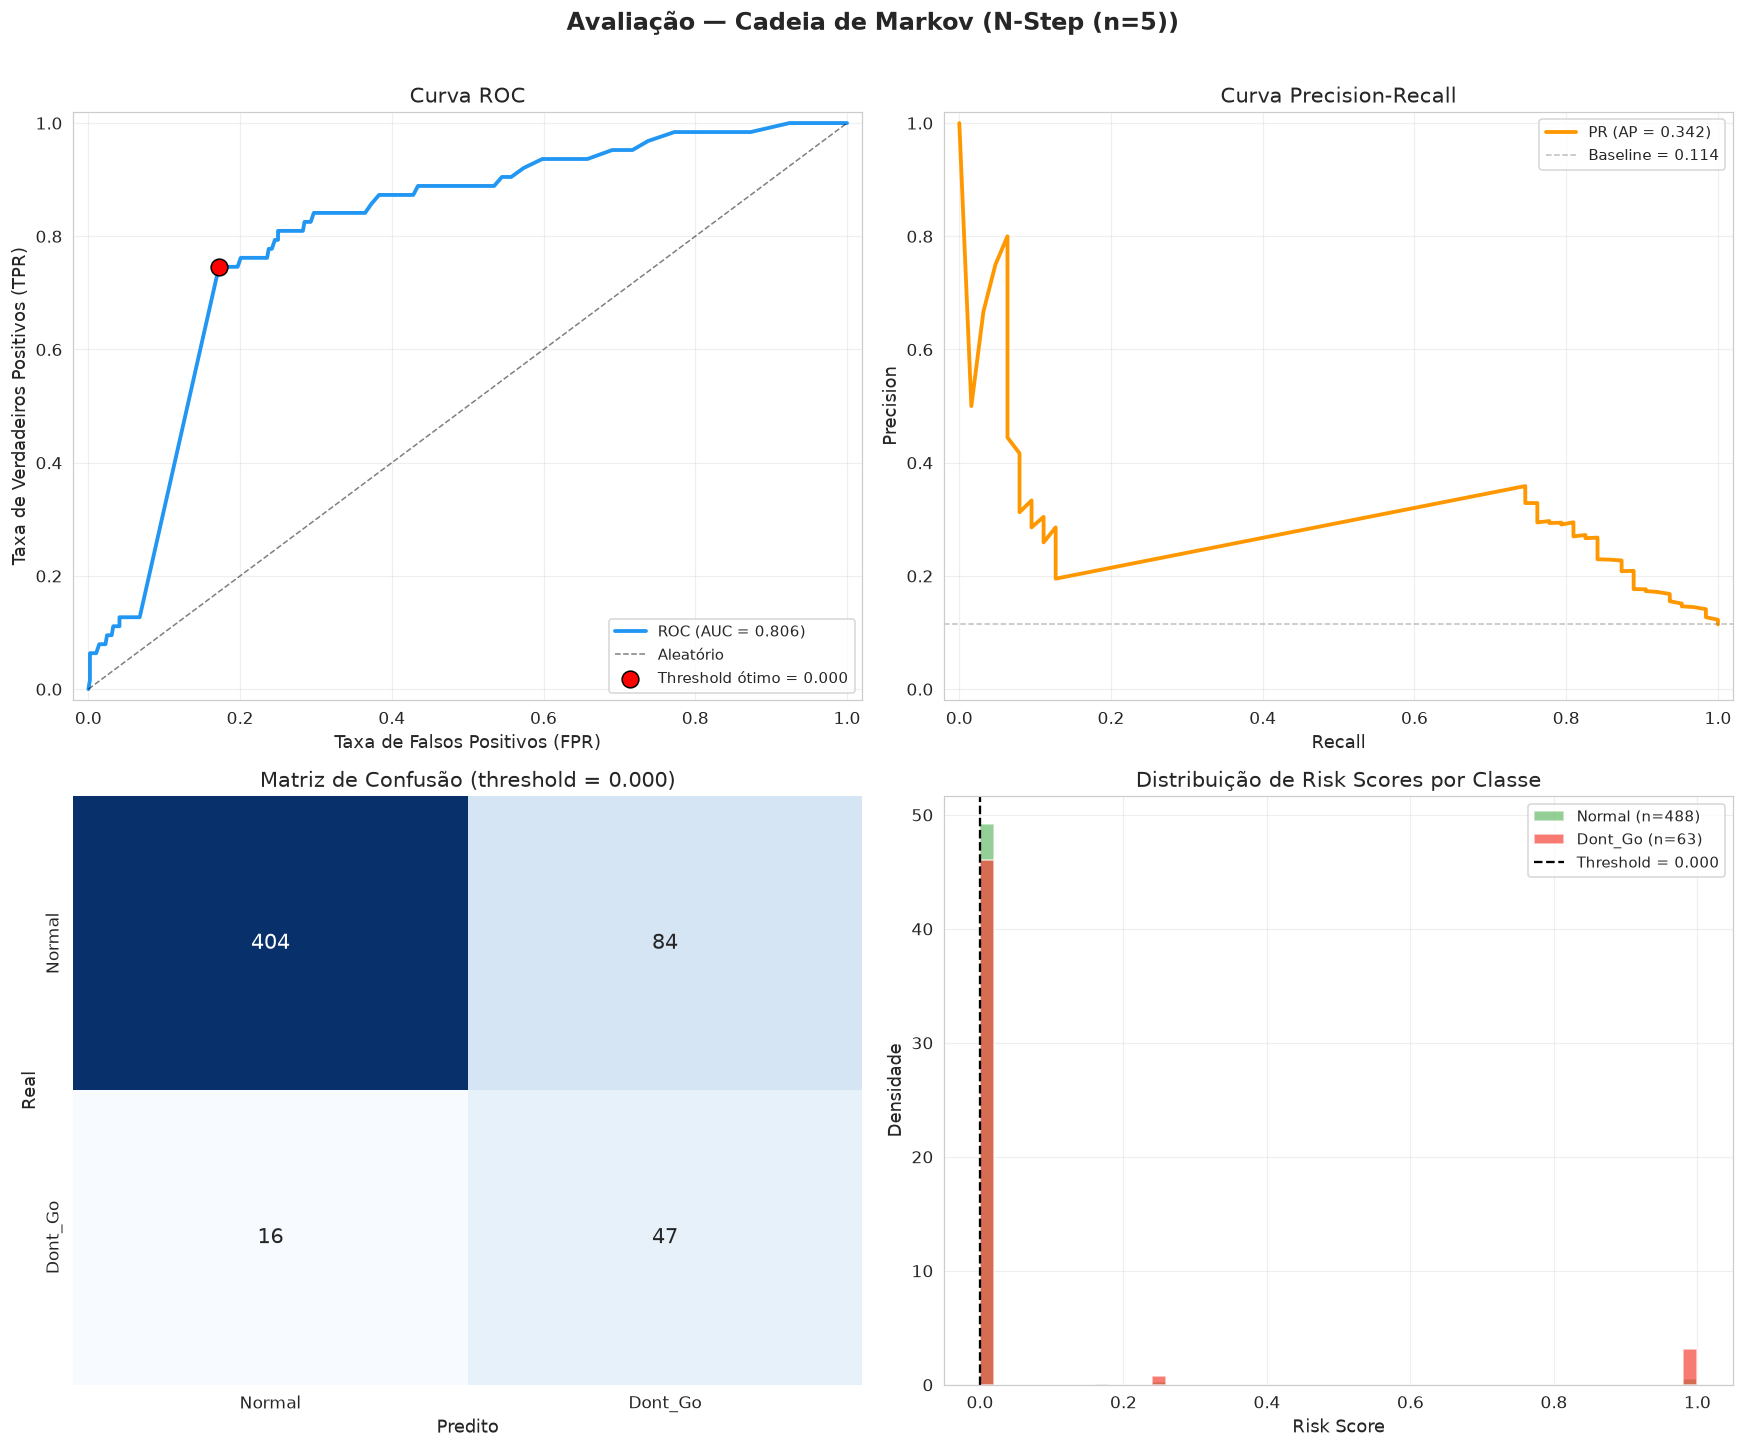


📊 AVALIAÇÃO — Método: Absorção (∞)

   ROC-AUC:                0.5124
   Average Precision (AP): 0.1169
   Threshold ótimo (J):    1.0000
   Precision:              0.1170
   Recall:                 0.9524
   F1-Score:               0.2083

--- Classification Report ---
              precision    recall  f1-score   support

  Normal (0)       0.92      0.07      0.13       488
 Dont_Go (1)       0.12      0.95      0.21        63

    accuracy                           0.17       551
   macro avg       0.52      0.51      0.17       551
weighted avg       0.83      0.17      0.14       551



ValueError: Too many bins for data range. Cannot create 50 finite-sized bins.

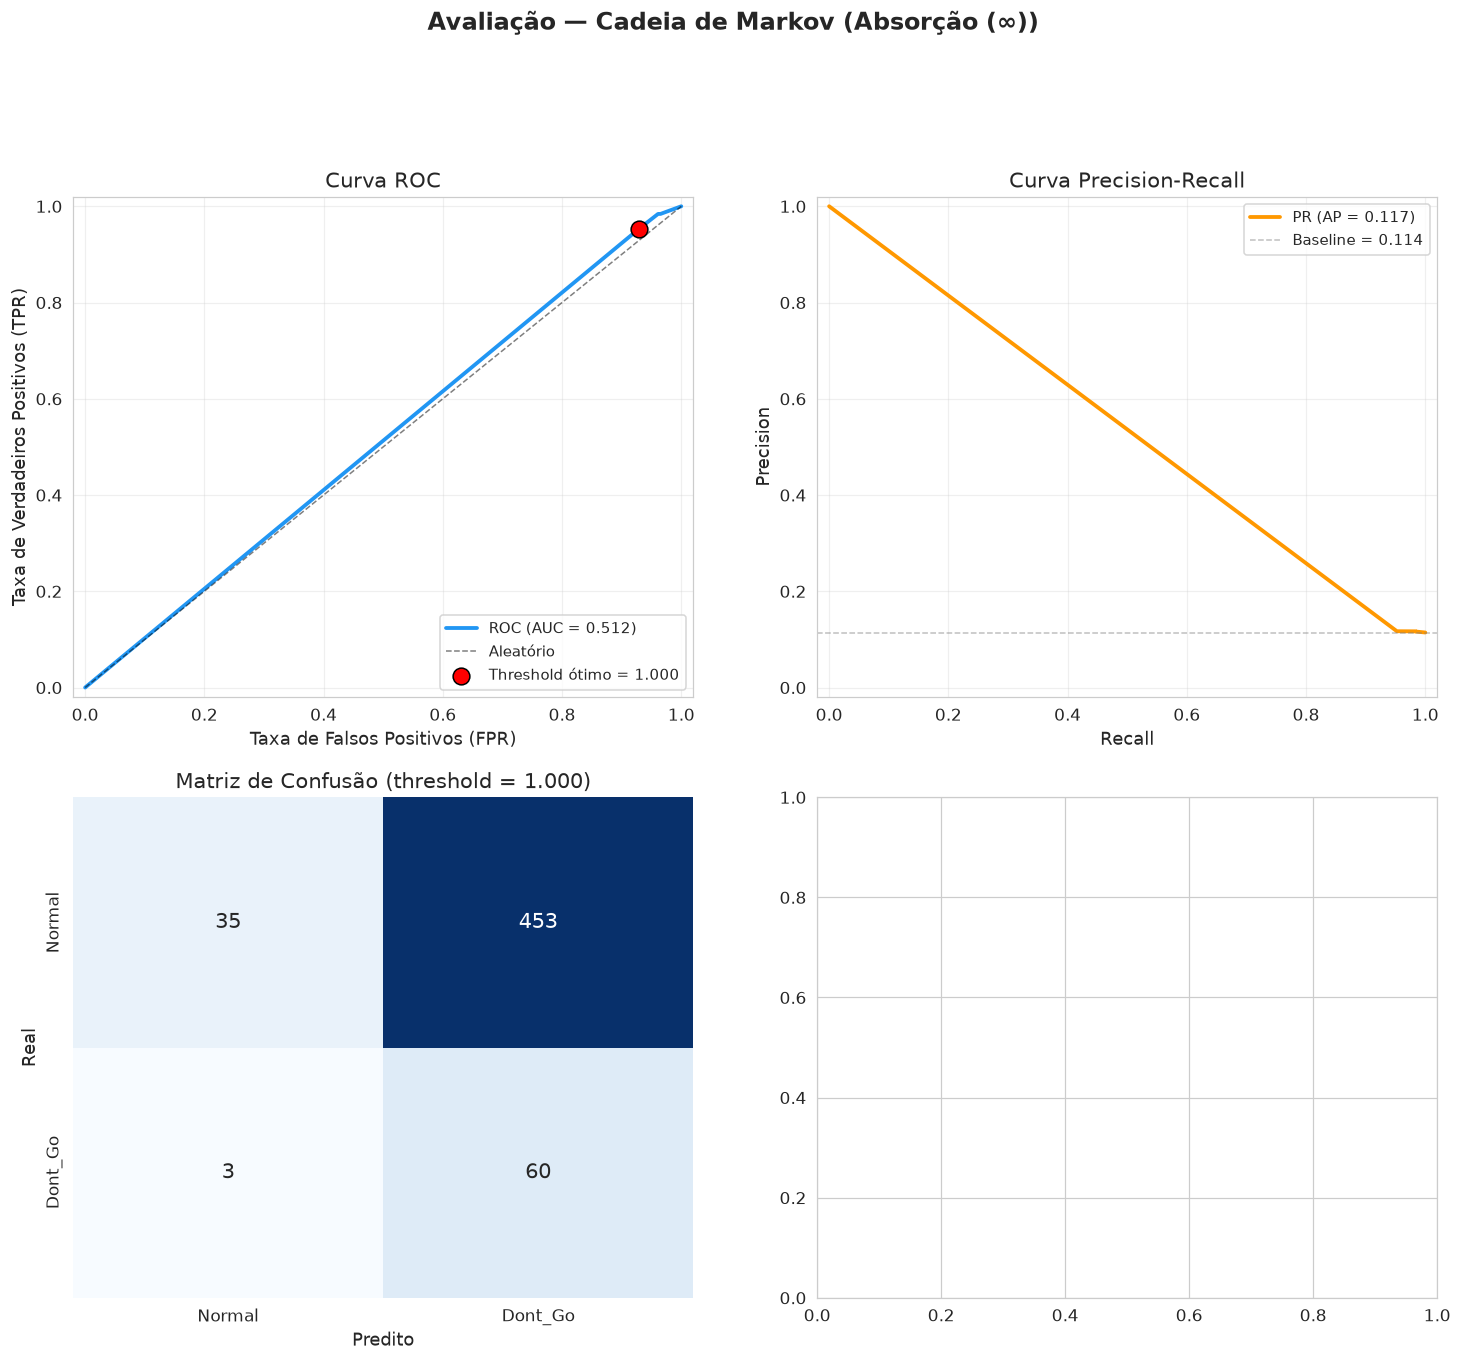

In [10]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                         AVALIAÇÃO DO MODELO                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

y_true = df_test["Target_4h"].values
y_scores_nstep = df_test["risk_nstep"].values
y_scores_absorb = df_test["risk_absorption"].values


def evaluate_and_plot(
    y_true: np.ndarray,
    y_scores: np.ndarray,
    method_name: str = "N-Step",
):
    """
    Avalia e visualiza os resultados do modelo Markov Chain.

    Inclui:
    - ROC-AUC e curva ROC
    - Precision-Recall e Average Precision
    - Threshold ótimo via Youden's J
    - Matriz de Confusão
    - Distribuição de scores por classe
    """
    print(f"\n{'='*70}")
    print(f"📊 AVALIAÇÃO — Método: {method_name}")
    print(f"{'='*70}")

    # ── Verificar se há classes suficientes ──
    if len(np.unique(y_true)) < 2:
        print("⚠️  Apenas uma classe presente no teste. Métricas ROC impossíveis.")
        return

    if np.all(y_scores == y_scores[0]):
        print("⚠️  Todos os scores são iguais. Modelo sem discriminação.")
        return

    # ═══════════════════════════════════════════════════════════════════════
    # MÉTRICAS NUMÉRICAS
    # ═══════════════════════════════════════════════════════════════════════

    # ROC-AUC
    roc_auc = roc_auc_score(y_true, y_scores)
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)

    # Precision-Recall
    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(
        y_true, y_scores
    )
    avg_precision = average_precision_score(y_true, y_scores)

    # Threshold ótimo via Youden's J statistic: argmax(TPR - FPR)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = roc_thresholds[best_idx]

    y_pred = (y_scores >= best_threshold).astype(int)

    print(f"\n   ROC-AUC:                {roc_auc:.4f}")
    print(f"   Average Precision (AP): {avg_precision:.4f}")
    print(f"   Threshold ótimo (J):    {best_threshold:.4f}")
    print(f"   Precision:              {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"   Recall:                 {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"   F1-Score:               {f1_score(y_true, y_pred, zero_division=0):.4f}")

    print(f"\n--- Classification Report ---")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["Normal (0)", "Dont_Go (1)"],
            zero_division=0,
        )
    )

    # ═══════════════════════════════════════════════════════════════════════
    # VISUALIZAÇÕES
    # ═══════════════════════════════════════════════════════════════════════

    fig, axes = plt.subplots(2, 2, figsize=(16, 13))
    fig.suptitle(
        f"Avaliação — Cadeia de Markov ({method_name})",
        fontsize=16,
        fontweight="bold",
        y=1.01,
    )

    # ── 1. Curva ROC ──
    ax1 = axes[0, 0]
    ax1.plot(fpr, tpr, color="#2196F3", lw=2.5, label=f"ROC (AUC = {roc_auc:.3f})")
    ax1.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Aleatório")
    ax1.scatter(
        fpr[best_idx],
        tpr[best_idx],
        s=120,
        c="red",
        zorder=5,
        label=f"Threshold ótimo = {best_threshold:.3f}",
        edgecolors="black",
    )
    ax1.set_xlabel("Taxa de Falsos Positivos (FPR)")
    ax1.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
    ax1.set_title("Curva ROC")
    ax1.legend(loc="lower right", fontsize=10)
    ax1.set_xlim([-0.02, 1.02])
    ax1.set_ylim([-0.02, 1.02])
    ax1.grid(True, alpha=0.3)

    # ── 2. Curva Precision-Recall ──
    ax2 = axes[0, 1]
    ax2.plot(
        recall_vals,
        precision_vals,
        color="#FF9800",
        lw=2.5,
        label=f"PR (AP = {avg_precision:.3f})",
    )
    ax2.axhline(
        y=y_true.mean(),
        color="gray",
        ls="--",
        lw=1,
        alpha=0.5,
        label=f"Baseline = {y_true.mean():.3f}",
    )
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title("Curva Precision-Recall")
    ax2.legend(loc="upper right", fontsize=10)
    ax2.set_xlim([-0.02, 1.02])
    ax2.set_ylim([-0.02, 1.02])
    ax2.grid(True, alpha=0.3)

    # ── 3. Matriz de Confusão ──
    ax3 = axes[1, 0]
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Dont_Go"],
        yticklabels=["Normal", "Dont_Go"],
        ax=ax3,
        cbar=False,
        annot_kws={"size": 14},
    )
    ax3.set_xlabel("Predito")
    ax3.set_ylabel("Real")
    ax3.set_title(f"Matriz de Confusão (threshold = {best_threshold:.3f})")

    # ── 4. Distribuição de Risk Scores ──
    ax4 = axes[1, 1]
    mask_0 = y_true == 0
    mask_1 = y_true == 1
    ax4.hist(
        y_scores[mask_0],
        bins=50,
        alpha=0.6,
        color="#4CAF50",
        label=f"Normal (n={mask_0.sum()})",
        density=True,
    )
    ax4.hist(
        y_scores[mask_1],
        bins=50,
        alpha=0.7,
        color="#F44336",
        label=f"Dont_Go (n={mask_1.sum()})",
        density=True,
    )
    ax4.axvline(
        x=best_threshold,
        color="black",
        ls="--",
        lw=1.5,
        label=f"Threshold = {best_threshold:.3f}",
    )
    ax4.set_xlabel("Risk Score")
    ax4.set_ylabel("Densidade")
    ax4.set_title("Distribuição de Risk Scores por Classe")
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "roc_auc": roc_auc,
        "avg_precision": avg_precision,
        "best_threshold": best_threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


# ── Avaliar método N-Step ──
metrics_nstep = evaluate_and_plot(y_true, y_scores_nstep, "N-Step (n=5)")

# ── Avaliar método Absorção ──
metrics_absorb = evaluate_and_plot(y_true, y_scores_absorb, "Absorção (∞)")


# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZAÇÃO EXTRA: Heatmap da Matriz de Transição (Top Estados)
# ═══════════════════════════════════════════════════════════════════════════

def plot_transition_heatmap(model: MarkovChainPredictor, top_n: int = 15):
    """
    Plota o heatmap da Matriz de Transição para os estados mais frequentes.
    """
    # Selecionar top_n estados + estado absorvente
    state_counts = df_train["state"].value_counts()
    top_states = list(state_counts.head(top_n).index)

    if model.ABSORBING_STATE not in top_states:
        top_states.append(model.ABSORBING_STATE)

    # Filtrar matriz
    indices = [model.state_to_idx_[s] for s in top_states if s in model.state_to_idx_]
    sub_P = model.P_[np.ix_(indices, indices)]
    labels = [top_states[i] if i < len(top_states) else "?" for i in range(len(indices))]

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(
        sub_P,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        linewidths=0.5,
        annot_kws={"size": 8},
        cbar_kws={"label": "P(transição)"},
    )
    ax.set_title(
        f"Matriz de Transição — Top {top_n} Estados + Absorvente",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Estado Destino (to)")
    ax.set_ylabel("Estado Origem (from)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


plot_transition_heatmap(mc_model, top_n=12)


# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZAÇÃO EXTRA: Evolução do Risco ao Longo do Tempo (1 caminhão)
# ═══════════════════════════════════════════════════════════════════════════

def plot_risk_timeline(df_test_subset: pd.DataFrame, tag: str):
    """
    Plota a evolução temporal do risk score para um caminhão específico,
    destacando os eventos Is_Dont_Go reais.
    """
    truck = df_test_subset[df_test_subset["TAG"] == tag].sort_values("Data_Evento")

    if truck.empty:
        print(f"⚠️  TAG '{tag}' não encontrado no conjunto de teste.")
        return

    fig, ax = plt.subplots(figsize=(16, 5))

    # Risk score ao longo do tempo
    ax.plot(
        truck["Data_Evento"],
        truck["risk_nstep"],
        color="#2196F3",
        lw=1.5,
        alpha=0.8,
        label="Risk Score (N-Step)",
    )
    ax.fill_between(
        truck["Data_Evento"],
        truck["risk_nstep"],
        alpha=0.15,
        color="#2196F3",
    )

    # Marcar eventos Is_Dont_Go
    dg_events = truck[truck["Is_Dont_Go"] == 1]
    if not dg_events.empty:
        ax.scatter(
            dg_events["Data_Evento"],
            dg_events["risk_nstep"],
            color="red",
            s=100,
            zorder=5,
            marker="X",
            label="Is_Dont_Go = 1",
            edgecolors="black",
        )

    # Marcar Target_4h = 1 (janela de risco)
    target_events = truck[truck["Target_4h"] == 1]
    if not target_events.empty:
        for _, row in target_events.iterrows():
            ax.axvspan(
                row["Data_Evento"],
                row["Data_Evento"] + pd.Timedelta(minutes=30),
                alpha=0.08,
                color="red",
            )

    ax.set_xlabel("Data/Hora")
    ax.set_ylabel("Risk Score")
    ax.set_title(
        f"Evolução Temporal do Risco — {tag}",
        fontsize=14,
        fontweight="bold",
    )
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Plotar para o primeiro TAG disponível no teste
test_tags = df_test["TAG"].unique()
if len(test_tags) > 0:
    plot_risk_timeline(df_test, test_tags[0])


# ═══════════════════════════════════════════════════════════════════════════
# RESUMO COMPARATIVO FINAL
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}")
print("📋 RESUMO COMPARATIVO — Cadeias de Markov para Is_Dont_Go")
print(f"{'='*70}")

summary_data = {
    "Métrica": ["ROC-AUC", "Avg. Precision", "Precision", "Recall", "F1-Score"],
}

if metrics_nstep:
    summary_data["N-Step (n=5)"] = [
        f"{metrics_nstep['roc_auc']:.4f}",
        f"{metrics_nstep['avg_precision']:.4f}",
        f"{metrics_nstep['precision']:.4f}",
        f"{metrics_nstep['recall']:.4f}",
        f"{metrics_nstep['f1']:.4f}",
    ]

if metrics_absorb:
    summary_data["Absorção (∞)"] = [
        f"{metrics_absorb['roc_auc']:.4f}",
        f"{metrics_absorb['avg_precision']:.4f}",
        f"{metrics_absorb['precision']:.4f}",
        f"{metrics_absorb['recall']:.4f}",
        f"{metrics_absorb['f1']:.4f}",
    ]

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print(f"\n{'='*70}")
print("✅ Análise concluída!")
print(f"   Estados no modelo:       {mc_model.n_states_}")
print(f"   Transições observadas:   {int(mc_model.count_matrix_.sum()):,}")
print(f"   Linhas de treino:        {len(df_train):,}")
print(f"   Linhas de teste:         {len(df_test):,}")
print(f"{'='*70}")